# **Prediction of Drug Response in Cancer Cell Lines using Machine Learning**

# **Business problem**

**Background**

Selecting effective drugs for different cancer types is one of the main challenges in modern oncology. Laboratory experiments to test thousands of drug combinations are expensive, time-consuming, and limited in scale.

The Genomics of Drug Sensitivity in Cancer (GDSC) dataset contains experimental data on:

- Cancer cell lines

- Tissue types (TCGA classification)

- Tested drugs

- **Drug response metrics (LN_IC50, AUC, Z_SCORE)**

- Molecular targets and biological pathways

These data enable the application of Machine Learning techniques to predict drug response in cancer cells.

**Project Objectives**

To develop predictive models capable of estimating drug effectiveness for different cancer types by addressing two main problems:

**Objective 1 — Regression**

Predict quantitatively the drug sensitivity using:

- **LN_IC50 (or AUC)**

This metric represents the drug concentration required to inhibit cell growth.

**Objective 2 — Classification**

Classify drug response into clinical categories such as:

- Sensitive

- Resistant

Derived from the Z_SCORE variable converted into a categorical target.

**Business Questions**

This project aims to answer:

**1. Can we predict the response of a cancer cell line to a specific drug?**

**2. Which drugs are more likely to be effective for particular cancer types?**

**3. Which molecular pathways (TARGET_PATHWAY) are associated with better therapeutic responses?**

**4. Can Machine Learning models reduce the cost and time required for drug screening?**

**Features and Targets**

**Input Features**

**CELL_LINE_NAME**

**TCGA_DESC**

**DRUG_NAME**

**TARGET**

**TARGET_PATHWAY**

**SITE**

**HISTOLOGY**

**GDSC_TISSUE_DESCRIPTOR_1**

**GDSC_TISSUE_DESCRIPTOR_2**

**CANCER_TYPE_MATCHING_TCGA_LABEL**

**Target Variables**

**Regression: LN_IC50 or AUC**

**Classification: Sensitive vs Resistant (derived from Z_SCORE)**

**Expected Benefits**

- Support precision medicine

- Reduce experimental costs

- Prioritize promising drugs

- Automate drug screening

- Provide biologically meaningful insights


**Limitations**

- Data represents cell lines rather than real patients

- Possible class imbalance

- Limited generalization to new clinical scenarios

# **Section A) Data Engineering**

# **Part 1 - ETL**

In [1]:
import os
import pandas as pd
from tqdm import tqdm

tqdm.pandas()

base_path = "/kaggle/input/genomics-of-drug-sensitivity-in-cancer-gdsc"
output_path = "/kaggle/working"

excel_path = os.path.join(base_path, "Cell_Lines_Details.xlsx")
compounds_path = os.path.join(base_path, "Compounds-annotation.csv")
gdsc1_path = os.path.join(base_path, "GDSC_DATASET.csv")
gdsc2_path = os.path.join(base_path, "GDSC2-dataset.csv")

output_csv = os.path.join(output_path, "gdsc_final_dataset1.csv")
output_excel = os.path.join(output_path, "gdsc_final_dataset1.xlsx")

def clean_columns(df):
    df.columns = (
        df.columns.astype(str)
        .str.strip()
        .str.upper()
        .str.replace("\n", "_")
        .str.replace(" ", "_")
        .str.replace("(", "")
        .str.replace(")", "")
    )
    return df

def merge_columns(df, col_base):
    col_x = f"{col_base}_X"
    col_y = f"{col_base}_Y"
    if col_x in df.columns and col_y in df.columns:
        return df[col_x].combine_first(df[col_y])
    elif col_x in df.columns:
        return df[col_x]
    elif col_y in df.columns:
        return df[col_y]
    else:
        return None
        
# ETL PIPELINE STEPS
steps = [
    "Reading Excel sheets",
    "Reading CSV files",
    "Cleaning column names",
    "Merging datasets",
    "Fixing duplicated columns",
    "Selecting final columns",
    "Saving CSV and Excel"
]

for step in tqdm(steps, desc="ETL Progress"):
    
    if step == "Reading Excel sheets":
        sheets = pd.read_excel(excel_path, sheet_name=None)
        cell_lines = sheets["Cell line details"]
        cosmic_tissue = sheets["COSMIC tissue classification"]
        tcga_decode = sheets["Decode"]

    elif step == "Reading CSV files":
        compounds = pd.read_csv(compounds_path)
        gdsc1 = pd.read_csv(gdsc1_path)
        gdsc2 = pd.read_csv(gdsc2_path)

    elif step == "Cleaning column names":
        cell_lines = clean_columns(cell_lines)
        cosmic_tissue = clean_columns(cosmic_tissue)
        tcga_decode = clean_columns(tcga_decode)
        compounds = clean_columns(compounds)
        gdsc1 = clean_columns(gdsc1)
        gdsc2 = clean_columns(gdsc2)

    elif step == "Merging datasets":
        cell_info = pd.merge(
            cell_lines,
            cosmic_tissue,
            left_on="COSMIC_IDENTIFIER",
            right_on="COSMIC_ID",
            how="left"
        )

        gdsc_full = pd.concat([gdsc1, gdsc2], ignore_index=True)

        gdsc_full = pd.merge(gdsc_full, compounds, on="DRUG_ID", how="left")
        gdsc_full = pd.merge(gdsc_full, cell_info, on="COSMIC_ID", how="left")

        print("\nAVAILABLE COLUMNS:")
        print(gdsc_full.columns.tolist())

    elif step == "Fixing duplicated columns":
        gdsc_full.columns = gdsc_full.columns.str.upper()

        gdsc_full["DRUG_NAME"] = merge_columns(gdsc_full, "DRUG_NAME")
        gdsc_full["TARGET"] = merge_columns(gdsc_full, "TARGET")
        gdsc_full["TARGET_PATHWAY"] = merge_columns(gdsc_full, "TARGET_PATHWAY")

        gdsc_full["GDSC_TISSUE_DESCRIPTOR_1"] = merge_columns(gdsc_full, "GDSC_TISSUE_DESCRIPTOR_1")
        gdsc_full["GDSC_TISSUE_DESCRIPTOR_2"] = merge_columns(gdsc_full, "GDSC_TISSUE_DESCRIPTOR_2")
        gdsc_full["CANCER_TYPE_MATCHING_TCGA_LABEL"] = merge_columns(gdsc_full, "CANCER_TYPE_MATCHING_TCGA_LABEL")

    elif step == "Selecting final columns":
        final_cols = [
            "COSMIC_ID",
            "CELL_LINE_NAME",
            "TCGA_DESC",
            "DRUG_ID",
            "DRUG_NAME",
            "LN_IC50",
            "AUC",
            "Z_SCORE",
            "TARGET",
            "TARGET_PATHWAY",
            "SITE",
            "HISTOLOGY",
            "GDSC_TISSUE_DESCRIPTOR_1",
            "GDSC_TISSUE_DESCRIPTOR_2",
            "CANCER_TYPE_MATCHING_TCGA_LABEL"
        ]

        existing_cols = [c for c in final_cols if c in gdsc_full.columns]
        final_df = gdsc_full[existing_cols]

        print("\nFINAL COLUMNS:")
        print(existing_cols)

    elif step == "Saving CSV and Excel":
        final_df.to_csv(output_csv, index=False)
        final_df.to_excel(output_excel, index=False)

print("\nETL COMPLETED SUCCESSFULLY")
print("Saved to:")
print(output_csv)
print(output_excel)

ETL Progress:   0%|          | 0/7 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
ETL Progress:  71%|███████▏  | 5/7 [00:05<00:01,  1.16it/s]


AVAILABLE COLUMNS:
['COSMIC_ID', 'CELL_LINE_NAME', 'TCGA_DESC', 'DRUG_ID', 'DRUG_NAME_x', 'LN_IC50', 'AUC', 'Z_SCORE', 'GDSC_TISSUE_DESCRIPTOR_1_x', 'GDSC_TISSUE_DESCRIPTOR_2_x', 'CANCER_TYPE_MATCHING_TCGA_LABEL_x', 'MICROSATELLITE_INSTABILITY_STATUS_MSI', 'SCREEN_MEDIUM_x', 'GROWTH_PROPERTIES_x', 'CNA', 'GENE_EXPRESSION_x', 'METHYLATION_x', 'TARGET_x', 'TARGET_PATHWAY_x', 'DATASET', 'NLME_RESULT_ID', 'NLME_CURVE_ID', 'SANGER_MODEL_ID', 'PUTATIVE_TARGET', 'PATHWAY_NAME', 'COMPANY_ID', 'WEBRELEASE', 'MIN_CONC', 'MAX_CONC', 'RMSE', 'SCREENING_SITE', 'DRUG_NAME_y', 'SYNONYMS', 'TARGET_y', 'TARGET_PATHWAY_y', 'SAMPLE_NAME', 'COSMIC_IDENTIFIER', 'WHOLE_EXOME_SEQUENCING_WES', 'COPY_NUMBER_ALTERATIONS_CNA', 'GENE_EXPRESSION_y', 'METHYLATION_y', 'DRUG_RESPONSE', 'GDSC_TISSUE_DESCRIPTOR_1_y', 'GDSC_TISSUE_DESCRIPTOR_2_y', 'CANCER_TYPE_MATCHING_TCGA_LABEL_y', 'MICROSATELLITE__INSTABILITY_STATUS_MSI', 'SCREEN_MEDIUM_y', 'GROWTH_PROPERTIES_y', 'LINE', 'SITE', 'HISTOLOGY']

FINAL COLUMNS:
['COSMIC

ETL Progress: 100%|██████████| 7/7 [02:17<00:00, 19.71s/it]


ETL COMPLETED SUCCESSFULLY
Saved to:
/kaggle/working/gdsc_final_dataset1.csv
/kaggle/working/gdsc_final_dataset1.xlsx


In [2]:
excel_path = "/kaggle/input/genomics-of-drug-sensitivity-in-cancer-gdsc/Cell_Lines_Details.xlsx"
output_path = "/kaggle/working/cell_lines_final_dataset.csv"

sheets = pd.read_excel(excel_path, sheet_name=None)

cell_lines = sheets["Cell line details"]
cosmic_tissue = sheets["COSMIC tissue classification"]
decode = sheets["Decode"]

def clean_columns(df):
    df.columns = (
        df.columns.astype(str)
        .str.strip()
        .str.upper()
        .str.replace(" ", "_")
        .str.replace("\n", "_")
        .str.replace("(", "")
        .str.replace(")", "")
    )
    return df

cell_lines = clean_columns(cell_lines)
cosmic_tissue = clean_columns(cosmic_tissue)
decode = clean_columns(decode)

df_merged = pd.merge(
    cell_lines,
    cosmic_tissue,
    left_on="COSMIC_IDENTIFIER",
    right_on="COSMIC_ID",
    how="left"
)

if "TCGA_TISSUE_CLASSIFICATION" in decode.columns:
    df_merged = pd.merge(
        df_merged,
        decode,
        on="TCGA_TISSUE_CLASSIFICATION",
        how="left"
    )

print("Columns after merge:")
print(df_merged.columns.tolist())

final_cols = [
    "SAMPLE_NAME",
    "COSMIC_IDENTIFIER",
    "COSMIC_ID",
    "SITE",
    "HISTOLOGY",
    "TCGA_TISSUE_CLASSIFICATION",
    "GDSC_TISSUE_DESCRIPTOR_1",
    "GDSC_TISSUE_DESCRIPTOR_2",
    "CANCER_TYPE_MATCHING_TCGA_LABEL",
    "MICROSATELLITE_INSTABILITY_STATUS_MSI"
]

final_cols = [c for c in final_cols if c in df_merged.columns]
final_df = df_merged[final_cols]

final_df.to_csv(output_path, index=False)

print("ETL completed successfully!")
print("Saved at:", output_path)
print("Final shape:", final_df.shape)


Columns after merge:
['SAMPLE_NAME', 'COSMIC_IDENTIFIER', 'WHOLE_EXOME_SEQUENCING_WES', 'COPY_NUMBER_ALTERATIONS_CNA', 'GENE_EXPRESSION', 'METHYLATION', 'DRUG_RESPONSE', 'GDSC_TISSUE_DESCRIPTOR_1', 'GDSC_TISSUE_DESCRIPTOR_2', 'CANCER_TYPE_MATCHING_TCGA_LABEL', 'MICROSATELLITE__INSTABILITY_STATUS_MSI', 'SCREEN_MEDIUM', 'GROWTH_PROPERTIES', 'LINE', 'COSMIC_ID', 'SITE', 'HISTOLOGY']
ETL completed successfully!
Saved at: /kaggle/working/cell_lines_final_dataset.csv
Final shape: (1002, 8)


/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


In [3]:
data1 = pd.read_csv("/kaggle/input/genomics-of-drug-sensitivity-in-cancer-gdsc/Compounds-annotation.csv")
data2 = pd.read_csv("/kaggle/input/genomics-of-drug-sensitivity-in-cancer-gdsc/GDSC2-dataset.csv")
data3 = pd.read_csv("/kaggle/input/genomics-of-drug-sensitivity-in-cancer-gdsc/GDSC_DATASET.csv")

def clean_columns(df):
    df.columns = (
        df.columns.astype(str)
        .str.strip()
        .str.upper()
        .str.replace(" ", "_")
        .str.replace("\n", "_")
        .str.replace("(", "")
        .str.replace(")", "")
    )
    return df

data1 = clean_columns(data1)
data2 = clean_columns(data2)
data3 = clean_columns(data3)

gdsc_full = pd.concat([data2, data3], ignore_index=True)

final_df = pd.merge(
    gdsc_full,
    data1,
    on="DRUG_ID",
    how="left"
)

def merge_columns(df, col_base):
    col_x = f"{col_base}_X"
    col_y = f"{col_base}_Y"
    if col_x in df.columns and col_y in df.columns:
        df[col_base] = df[col_x].combine_first(df[col_y])
        df.drop([col_x, col_y], axis=1, inplace=True)
    return df

for col in ["DRUG_NAME", "TARGET", "TARGET_PATHWAY"]:
    final_df = merge_columns(final_df, col)

if "LN_IC50" in final_df.columns:
    threshold = final_df["LN_IC50"].median()
    final_df["SENSITIVE"] = (final_df["LN_IC50"] <= threshold).astype(int)

    print("LN_IC50 threshold (median):", threshold)
    print(final_df["SENSITIVE"].value_counts())

final_cols = [
    "COSMIC_ID",
    "CELL_LINE_NAME",
    "TCGA_DESC",
    "DRUG_ID",
    "DRUG_NAME",
    "TARGET",
    "TARGET_PATHWAY",
    "LN_IC50",
    "SENSITIVE",
    "AUC",
    "Z_SCORE"
]

final_cols = [c for c in final_cols if c in final_df.columns]
final_df = final_df[final_cols]

output_path = "/kaggle/working/gdsc_final_dataset_with_target2.csv"
final_df.to_csv(output_path, index=False)

print("ETL completed successfully!")
print("Saved at:", output_path)
print("Final shape:", final_df.shape)

LN_IC50 threshold (median): 3.236744
SENSITIVE
1    242037
0    242034
Name: count, dtype: int64
ETL completed successfully!
Saved at: /kaggle/working/gdsc_final_dataset_with_target2.csv
Final shape: (484071, 8)


In [4]:
BASE_PATH = "/kaggle/input/genomics-of-drug-sensitivity-in-cancer-gdsc/"
OUTPUT_PATH = "/kaggle/working/GDSC_ETL_FULL_FINAL.csv"

GDSC2_FILE = "GDSC2-dataset.csv"
COMPOUNDS_FILE = "Compounds-annotation.csv"
CELL_LINES_FILE = "Cell_Lines_Details.xlsx"

def clean_columns(df):
    df.columns = (
        df.columns.astype(str)
        .str.strip()
        .str.upper()
        .str.replace(" ", "_")
        .str.replace("\n", "_")
        .str.replace("(", "")
        .str.replace(")", "")
    )
    return df

print("Loading datasets...")

gdsc2 = pd.read_csv(os.path.join(BASE_PATH, GDSC2_FILE))
compounds = pd.read_csv(os.path.join(BASE_PATH, COMPOUNDS_FILE))
cell_lines = pd.read_excel(os.path.join(BASE_PATH, CELL_LINES_FILE))

gdsc2 = clean_columns(gdsc2)
compounds = clean_columns(compounds)
cell_lines = clean_columns(cell_lines)

print("GDSC2 shape:", gdsc2.shape)
print("Compounds shape:", compounds.shape)
print("Cell lines shape:", cell_lines.shape)

print("\nCell lines columns:")
print(cell_lines.columns.tolist())

# SELECT COLUMNS

gdsc2_cols = [
    "COSMIC_ID",
    "CELL_LINE_NAME",
    "TCGA_DESC",
    "DRUG_ID",
    "DRUG_NAME",
    "PUTATIVE_TARGET",
    "PATHWAY_NAME",
    "LN_IC50",
    "AUC",
    "Z_SCORE"
]
gdsc2 = gdsc2[gdsc2_cols]

compound_cols = [
    "DRUG_ID",
    "TARGET",
    "TARGET_PATHWAY"
]
compounds = compounds[compound_cols]

cell_cols = [
    "COSMIC_IDENTIFIER",
    "GDSC_TISSUE_DESCRIPTOR_1",
    "GDSC_TISSUE_DESCRIPTOR_2",
    "CANCER_TYPE_MATCHING_TCGA_LABEL",
    "MICROSATELLITE__INSTABILITY_STATUS_MSI",
    "SCREEN_MEDIUM",
    "GROWTH_PROPERTIES",
    "COPY_NUMBER_ALTERATIONS_CNA",
    "GENE_EXPRESSION",
    "METHYLATION"
]
cell_lines = cell_lines[cell_cols]

cell_lines = cell_lines.rename(columns={
    "COSMIC_IDENTIFIER": "COSMIC_ID",
    "COPY_NUMBER_ALTERATIONS_CNA": "CNA"
})

df = gdsc2.merge(compounds, on="DRUG_ID", how="left")
df = df.merge(cell_lines, on="COSMIC_ID", how="left")

print("After merge shape:", df.shape)

df = df.drop_duplicates()
df = df.dropna(subset=["LN_IC50"])

median_ic50 = df["LN_IC50"].median()
df["LABEL"] = (df["LN_IC50"] < median_ic50).astype(int)

leak_cols = [ "Z_SCORE"]
df_ml = df.drop(columns=leak_cols, errors="ignore")

print("\nFinal dataset shape:", df_ml.shape)

print("\nMissing values per column:")
print(df_ml.isna().sum())

print("\nLabel distribution:")
print(df_ml["LABEL"].value_counts())

df_ml.to_csv(OUTPUT_PATH, index=False)

print("\nETL completed successfully.")
print("Saved file to:", OUTPUT_PATH)

Loading datasets...


/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


GDSC2 shape: (242036, 19)
Compounds shape: (621, 6)
Cell lines shape: (1002, 13)

Cell lines columns:
['SAMPLE_NAME', 'COSMIC_IDENTIFIER', 'WHOLE_EXOME_SEQUENCING_WES', 'COPY_NUMBER_ALTERATIONS_CNA', 'GENE_EXPRESSION', 'METHYLATION', 'DRUG_RESPONSE', 'GDSC_TISSUE_DESCRIPTOR_1', 'GDSC_TISSUE_DESCRIPTOR_2', 'CANCER_TYPE_MATCHING_TCGA_LABEL', 'MICROSATELLITE__INSTABILITY_STATUS_MSI', 'SCREEN_MEDIUM', 'GROWTH_PROPERTIES']
After merge shape: (242036, 21)

Final dataset shape: (242036, 21)

Missing values per column:
COSMIC_ID                                     0
CELL_LINE_NAME                                0
TCGA_DESC                                  1067
DRUG_ID                                       0
DRUG_NAME                                     0
PUTATIVE_TARGET                           27155
PATHWAY_NAME                                  0
LN_IC50                                       0
AUC                                           0
TARGET                                    27155
TAR

# **Section B) Machine Learning Model - Classification**

# **Part 2 - Database**

In [5]:
import os
import joblib
from tqdm import tqdm

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Classification models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# Regression models
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor

from sklearn.metrics import (
    accuracy_score, recall_score, f1_score,
    roc_curve, auc, classification_report,
    roc_auc_score, confusion_matrix,
    mean_squared_error, r2_score,
    mean_absolute_error
)

sns.set(style="whitegrid")

In [6]:
df = pd.read_csv("/kaggle/working/GDSC_ETL_FULL_FINAL.csv")
df

,COSMIC_ID,CELL_LINE_NAME,TCGA_DESC,DRUG_ID,DRUG_NAME,PUTATIVE_TARGET,PATHWAY_NAME,LN_IC50,AUC,TARGET,...,GDSC_TISSUE_DESCRIPTOR_1,GDSC_TISSUE_DESCRIPTOR_2,CANCER_TYPE_MATCHING_TCGA_LABEL,MICROSATELLITE__INSTABILITY_STATUS_MSI,SCREEN_MEDIUM,GROWTH_PROPERTIES,CNA,GENE_EXPRESSION,METHYLATION,LABEL
0,683667,PFSK-1,MB,1003,Camptothecin,TOP1,DNA replication,-1.463887,0.930220,TOP1,...,nervous_system,medulloblastoma,MB,MSS/MSI-L,R,Adherent,Y,Y,Y,1
1,684052,A673,UNCLASSIFIED,1003,Camptothecin,TOP1,DNA replication,-4.869455,0.614970,TOP1,...,soft_tissue,rhabdomyosarcoma,NaN,MSS/MSI-L,D/F12,Adherent,Y,Y,Y,1
2,684057,ES5,UNCLASSIFIED,1003,Camptothecin,TOP1,DNA replication,-3.360586,0.791072,TOP1,...,bone,ewings_sarcoma,NaN,MSS/MSI-L,R,Adherent,Y,Y,Y,1
3,684059,ES7,UNCLASSIFIED,1003,Camptothecin,TOP1,DNA replication,-5.044940,0.592660,TOP1,...,bone,ewings_sarcoma,NaN,MSS/MSI-L,R,Adherent,Y,Y,Y,1
4,684062,EW-11,UNCLASSIFIED,1003,Camptothecin,TOP1,DNA replication,-3.741991,0.734047,TOP1,...,bone,ewings_sarcoma,NaN,MSS/MSI-L,R,Adherent,Y,Y,Y,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
242031,1659928,SNU-175,COREAD,2499,N-acetyl cysteine,Metabolism,Metabolism,10.127082,0.976746,Metabolism,...,large_intestine,large_intestine,COAD/READ,MSI-H,R,Suspension,Y,Y,Y,0
242032,1660034,SNU-407,COREAD,2499,N-acetyl cysteine,Metabolism,Metabolism,8.576377,0.913378,Metabolism,...,large_intestine,large_intestine,COAD/READ,MSI-H,R,Adherent,Y,Y,Y,0
242033,1660035,SNU-61,COREAD,2499,N-acetyl cysteine,Metabolism,Metabolism,10.519636,0.975001,Metabolism,...,large_intestine,large_intestine,COAD/READ,MSS/MSI-L,R,Adherent,Y,Y,Y,0
242034,1674021,SNU-C5,COREAD,2499,N-acetyl cysteine,Metabolism,Metabolism,10.694579,0.969969,Metabolism,...,large_intestine,large_intestine,COAD/READ,MSI-H,R,Adherent,Y,Y,Y,0


In [7]:
print(df.columns)

Index(['COSMIC_ID', 'CELL_LINE_NAME', 'TCGA_DESC', 'DRUG_ID', 'DRUG_NAME',
       'PUTATIVE_TARGET', 'PATHWAY_NAME', 'LN_IC50', 'AUC', 'TARGET',
       'TARGET_PATHWAY', 'GDSC_TISSUE_DESCRIPTOR_1',
       'GDSC_TISSUE_DESCRIPTOR_2', 'CANCER_TYPE_MATCHING_TCGA_LABEL',
       'MICROSATELLITE__INSTABILITY_STATUS_MSI', 'SCREEN_MEDIUM',
       'GROWTH_PROPERTIES', 'CNA', 'GENE_EXPRESSION', 'METHYLATION', 'LABEL'],
      dtype='object')


In [8]:
df.head()

,COSMIC_ID,CELL_LINE_NAME,TCGA_DESC,DRUG_ID,DRUG_NAME,PUTATIVE_TARGET,PATHWAY_NAME,LN_IC50,AUC,TARGET,...,GDSC_TISSUE_DESCRIPTOR_1,GDSC_TISSUE_DESCRIPTOR_2,CANCER_TYPE_MATCHING_TCGA_LABEL,MICROSATELLITE__INSTABILITY_STATUS_MSI,SCREEN_MEDIUM,GROWTH_PROPERTIES,CNA,GENE_EXPRESSION,METHYLATION,LABEL
0,683667,PFSK-1,MB,1003,Camptothecin,TOP1,DNA replication,-1.463887,0.930220,TOP1,...,nervous_system,medulloblastoma,MB,MSS/MSI-L,R,Adherent,Y,Y,Y,1
1,684052,A673,UNCLASSIFIED,1003,Camptothecin,TOP1,DNA replication,-4.869455,0.614970,TOP1,...,soft_tissue,rhabdomyosarcoma,NaN,MSS/MSI-L,D/F12,Adherent,Y,Y,Y,1
2,684057,ES5,UNCLASSIFIED,1003,Camptothecin,TOP1,DNA replication,-3.360586,0.791072,TOP1,...,bone,ewings_sarcoma,NaN,MSS/MSI-L,R,Adherent,Y,Y,Y,1
3,684059,ES7,UNCLASSIFIED,1003,Camptothecin,TOP1,DNA replication,-5.044940,0.592660,TOP1,...,bone,ewings_sarcoma,NaN,MSS/MSI-L,R,Adherent,Y,Y,Y,1
4,684062,EW-11,UNCLASSIFIED,1003,Camptothecin,TOP1,DNA replication,-3.741991,0.734047,TOP1,...,bone,ewings_sarcoma,NaN,MSS/MSI-L,R,Adherent,Y,Y,Y,1


In [9]:
df.tail()

,COSMIC_ID,CELL_LINE_NAME,TCGA_DESC,DRUG_ID,DRUG_NAME,PUTATIVE_TARGET,PATHWAY_NAME,LN_IC50,AUC,TARGET,...,GDSC_TISSUE_DESCRIPTOR_1,GDSC_TISSUE_DESCRIPTOR_2,CANCER_TYPE_MATCHING_TCGA_LABEL,MICROSATELLITE__INSTABILITY_STATUS_MSI,SCREEN_MEDIUM,GROWTH_PROPERTIES,CNA,GENE_EXPRESSION,METHYLATION,LABEL
242031,1659928,SNU-175,COREAD,2499,N-acetyl cysteine,Metabolism,Metabolism,10.127082,0.976746,Metabolism,...,large_intestine,large_intestine,COAD/READ,MSI-H,R,Suspension,Y,Y,Y,0
242032,1660034,SNU-407,COREAD,2499,N-acetyl cysteine,Metabolism,Metabolism,8.576377,0.913378,Metabolism,...,large_intestine,large_intestine,COAD/READ,MSI-H,R,Adherent,Y,Y,Y,0
242033,1660035,SNU-61,COREAD,2499,N-acetyl cysteine,Metabolism,Metabolism,10.519636,0.975001,Metabolism,...,large_intestine,large_intestine,COAD/READ,MSS/MSI-L,R,Adherent,Y,Y,Y,0
242034,1674021,SNU-C5,COREAD,2499,N-acetyl cysteine,Metabolism,Metabolism,10.694579,0.969969,Metabolism,...,large_intestine,large_intestine,COAD/READ,MSI-H,R,Adherent,Y,Y,Y,0
242035,1789883,DiFi,COREAD,2499,N-acetyl cysteine,Metabolism,Metabolism,10.034825,0.966988,Metabolism,...,large_intestine,large_intestine,COAD/READ,MSS/MSI-L,D/F12,Adherent,Y,N,Y,0


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 242036 entries, 0 to 242035
Data columns (total 21 columns):
 #   Column                                  Non-Null Count   Dtype  
---  ------                                  --------------   -----  
 0   COSMIC_ID                               242036 non-null  int64  
 1   CELL_LINE_NAME                          242036 non-null  object 
 2   TCGA_DESC                               240969 non-null  object 
 3   DRUG_ID                                 242036 non-null  int64  
 4   DRUG_NAME                               242036 non-null  object 
 5   PUTATIVE_TARGET                         214881 non-null  object 
 6   PATHWAY_NAME                            242036 non-null  object 
 7   LN_IC50                                 242036 non-null  float64
 8   AUC                                     242036 non-null  float64
 9   TARGET                                  214881 non-null  object 
 10  TARGET_PATHWAY                          2420

In [11]:
df.dtypes

COSMIC_ID                                   int64
CELL_LINE_NAME                             object
TCGA_DESC                                  object
DRUG_ID                                     int64
DRUG_NAME                                  object
PUTATIVE_TARGET                            object
PATHWAY_NAME                               object
LN_IC50                                   float64
AUC                                       float64
TARGET                                     object
TARGET_PATHWAY                             object
GDSC_TISSUE_DESCRIPTOR_1                   object
GDSC_TISSUE_DESCRIPTOR_2                   object
CANCER_TYPE_MATCHING_TCGA_LABEL            object
MICROSATELLITE__INSTABILITY_STATUS_MSI     object
SCREEN_MEDIUM                              object
GROWTH_PROPERTIES                          object
CNA                                        object
GENE_EXPRESSION                            object
METHYLATION                                object


In [12]:
df.LABEL.value_counts()

LABEL
1    121018
0    121018
Name: count, dtype: int64

# **Part 3 - Outlier analysis with z-score**

In [13]:
from scipy.stats import zscore
num_cols = ['CNA', 'GENE_EXPRESSION', 'METHYLATION']

df_num = df[num_cols].copy()
print(df[num_cols].dtypes)

CNA                object
GENE_EXPRESSION    object
METHYLATION        object
dtype: object


In [14]:
num_cols = ['CNA', 'GENE_EXPRESSION', 'METHYLATION']

for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df_num = df[num_cols].copy()

z_scores = np.abs(zscore(df_num, nan_policy='omit'))
z_df = pd.DataFrame(z_scores, columns=num_cols)

outlier_mask = (z_df > 3).any(axis=1)

df_outliers = df[outlier_mask]
df_clean = df[~outlier_mask]

print("Total samples:", df.shape[0])
print("Detected outliers:", df_outliers.shape[0])
print("Samples after cleaning:", df_clean.shape[0])

Total samples: 242036
Detected outliers: 0
Samples after cleaning: 242036


- **Scatterplots comparing drug response metrics reveal that outliers (identified by Z-score > 3) are sparsely distributed and mainly occur at extreme values of LN_IC50 and Z_SCORE. This visualization supports the decision to treat or remove extreme observations prior to model training.**

# **Part 4 - Feature engineering**

In [15]:
cat_cols = df.select_dtypes(include=["object", "bool"]).columns
cat_cols

Index(['CELL_LINE_NAME', 'TCGA_DESC', 'DRUG_NAME', 'PUTATIVE_TARGET',
       'PATHWAY_NAME', 'TARGET', 'TARGET_PATHWAY', 'GDSC_TISSUE_DESCRIPTOR_1',
       'GDSC_TISSUE_DESCRIPTOR_2', 'CANCER_TYPE_MATCHING_TCGA_LABEL',
       'MICROSATELLITE__INSTABILITY_STATUS_MSI', 'SCREEN_MEDIUM',
       'GROWTH_PROPERTIES'],
      dtype='object')

In [16]:
le = LabelEncoder()

for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))

df.dtypes

le

LabelEncoder()

In [17]:
df

,COSMIC_ID,CELL_LINE_NAME,TCGA_DESC,DRUG_ID,DRUG_NAME,PUTATIVE_TARGET,PATHWAY_NAME,LN_IC50,AUC,TARGET,...,GDSC_TISSUE_DESCRIPTOR_1,GDSC_TISSUE_DESCRIPTOR_2,CANCER_TYPE_MATCHING_TCGA_LABEL,MICROSATELLITE__INSTABILITY_STATUS_MSI,SCREEN_MEDIUM,GROWTH_PROPERTIES,CNA,GENE_EXPRESSION,METHYLATION,LABEL
0,683667,736,18,1003,73,165,7,-1.463887,0.930220,165,...,12,37,18,1,1,0,NaN,NaN,NaN,1
1,684052,27,31,1003,73,165,7,-4.869455,0.614970,165,...,16,47,31,1,0,0,NaN,NaN,NaN,1
2,684057,199,31,1003,73,165,7,-3.360586,0.791072,165,...,1,18,31,1,1,0,NaN,NaN,NaN,1
3,684059,201,31,1003,73,165,7,-5.044940,0.592660,165,...,1,18,31,1,1,0,NaN,NaN,NaN,1
4,684062,209,31,1003,73,165,7,-3.741991,0.734047,165,...,1,18,31,1,1,0,NaN,NaN,NaN,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
242031,1659928,841,6,2499,172,112,14,10.127082,0.976746,112,...,5,25,6,0,1,2,NaN,NaN,NaN,0
242032,1660034,845,6,2499,172,112,14,8.576377,0.913378,112,...,5,25,6,0,1,0,NaN,NaN,NaN,0
242033,1660035,849,6,2499,172,112,14,10.519636,0.975001,112,...,5,25,6,1,1,0,NaN,NaN,NaN,0
242034,1674021,853,6,2499,172,112,14,10.694579,0.969969,112,...,5,25,6,0,1,0,NaN,NaN,NaN,0


# Part 5 - Division x and y

In [18]:
print(df.columns.tolist())

['COSMIC_ID', 'CELL_LINE_NAME', 'TCGA_DESC', 'DRUG_ID', 'DRUG_NAME', 'PUTATIVE_TARGET', 'PATHWAY_NAME', 'LN_IC50', 'AUC', 'TARGET', 'TARGET_PATHWAY', 'GDSC_TISSUE_DESCRIPTOR_1', 'GDSC_TISSUE_DESCRIPTOR_2', 'CANCER_TYPE_MATCHING_TCGA_LABEL', 'MICROSATELLITE__INSTABILITY_STATUS_MSI', 'SCREEN_MEDIUM', 'GROWTH_PROPERTIES', 'CNA', 'GENE_EXPRESSION', 'METHYLATION', 'LABEL']


In [19]:
drop_cols = [
    "LABEL",
    "CELL_LINE_NAME",
    "COSMIC_ID",
    "DRUG_ID",
]

ALL_FEATURES = df.drop(columns=drop_cols)

SELECTED_FEATURES = [
    "AUC",
    "DRUG_NAME",
    "TARGET",
    "TARGET_PATHWAY",
    "TCGA_DESC",
    "GDSC_TISSUE_DESCRIPTOR_2",
    "CANCER_TYPE_MATCHING_TCGA_LABEL",
    "SITE",
    "GDSC_TISSUE_DESCRIPTOR_1"
]

feature_map = {
    "SITE": "SCREEN_MEDIUM",
    "GDSC_TISSUE_DESCRIPTOR_1": "GDSC_TISSUE_DESCRIPTOR_1",
    "GDSC_TISSUE_DESCRIPTOR_2": "GDSC_TISSUE_DESCRIPTOR_2",
    "CANCER_TYPE_MATCHING_TCGA_LABEL": "CANCER_TYPE_MATCHING_TCGA_LABEL"
}

real_cols = []

for col in SELECTED_FEATURES:
    real_cols.append(feature_map.get(col, col))

X = ALL_FEATURES[real_cols].copy()

X.columns = SELECTED_FEATURES

y = df["LABEL"]

groups = df["DRUG_NAME"]

print("Selected features:")
print(X.columns.tolist())

print("X shape:", X.shape)
print(y.value_counts())

Selected features:
['AUC', 'DRUG_NAME', 'TARGET', 'TARGET_PATHWAY', 'TCGA_DESC', 'GDSC_TISSUE_DESCRIPTOR_2', 'CANCER_TYPE_MATCHING_TCGA_LABEL', 'SITE', 'GDSC_TISSUE_DESCRIPTOR_1']
X shape: (242036, 9)
LABEL
1    121018
0    121018
Name: count, dtype: int64


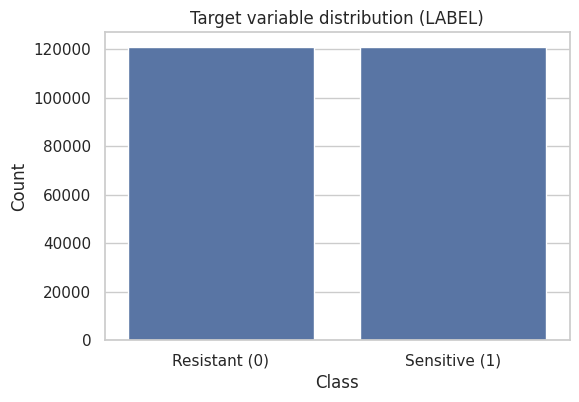

LABEL
1    121018
0    121018
Name: count, dtype: int64
LABEL
1    0.5
0    0.5
Name: proportion, dtype: float64


In [20]:
plt.figure(figsize=(6,4))

sns.countplot(x=df["LABEL"])

plt.title("Target variable distribution (LABEL)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks([0,1], ["Resistant (0)", "Sensitive (1)"])

plt.show()

print(df["LABEL"].value_counts())
print(df["LABEL"].value_counts(normalize=True))

# **Part 6 - Split GroupShuffleSplit**

In [21]:
from sklearn.model_selection import GroupShuffleSplit

groups = df["DRUG_NAME"]

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))

X_train = X.iloc[train_idx].copy()
X_test  = X.iloc[test_idx].copy()
y_train = y.iloc[train_idx]
y_test  = y.iloc[test_idx]

print(X_train.shape, X_test.shape)

(191595, 9) (50441, 9)


In [22]:
# Encode categorical features
from sklearn.preprocessing import OrdinalEncoder

cat_cols = X_train.select_dtypes(include="object").columns

encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)

X_train[cat_cols] = encoder.fit_transform(X_train[cat_cols])
X_test[cat_cols] = encoder.transform(X_test[cat_cols])

encoder

OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

# **Part 7 - Simple Imputer**

In [23]:
all_nan_cols = X_train.columns[X_train.isna().all()].tolist()

print("Columns removed (100% NaN):", all_nan_cols)

X_train = X_train.drop(columns=all_nan_cols)
X_test  = X_test.drop(columns=all_nan_cols)

num_cols = X_train.select_dtypes(include=["int64", "float64"]).columns

cat_cols = X_train.select_dtypes(include=["object"]).columns

X_train = X_train.dropna(axis=1, how="all")
X_test  = X_test.dropna(axis=1, how="all")

Columns removed (100% NaN): []


In [24]:
print("num_cols:", num_cols)
print("cat_cols:", cat_cols)

num_cols: Index(['AUC', 'DRUG_NAME', 'TARGET', 'TARGET_PATHWAY', 'TCGA_DESC',
       'GDSC_TISSUE_DESCRIPTOR_2', 'CANCER_TYPE_MATCHING_TCGA_LABEL', 'SITE',
       'GDSC_TISSUE_DESCRIPTOR_1'],
      dtype='object')
cat_cols: Index([], dtype='object')


In [25]:
from sklearn.impute import SimpleImputer

X_train = X_train.dropna(axis=1, how="all")
X_test  = X_test.dropna(axis=1, how="all")

num_cols = X_train.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X_train.select_dtypes(include=["object"]).columns

print("Numeric columns:", list(num_cols))
print("Categorical columns:", list(cat_cols))

num_imputer = SimpleImputer(strategy="median")
cat_imputer = SimpleImputer(strategy="most_frequent")

if len(num_cols) > 0:
    X_train[num_cols] = num_imputer.fit_transform(X_train[num_cols])
    X_test[num_cols]  = num_imputer.transform(X_test[num_cols])

if len(cat_cols) > 0:
    X_train[cat_cols] = cat_imputer.fit_transform(X_train[cat_cols])
    X_test[cat_cols]  = cat_imputer.transform(X_test[cat_cols])



Numeric columns: ['AUC', 'DRUG_NAME', 'TARGET', 'TARGET_PATHWAY', 'TCGA_DESC', 'GDSC_TISSUE_DESCRIPTOR_2', 'CANCER_TYPE_MATCHING_TCGA_LABEL', 'SITE', 'GDSC_TISSUE_DESCRIPTOR_1']
Categorical columns: []


In [26]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

scaler

StandardScaler()

In [27]:
for c in ["LABEL","LN_IC50","AUC"]:
    print(c, "in X?", c in X.columns)

LABEL in X? False
LN_IC50 in X? False
AUC in X? True


In [28]:
overlap = set(df.iloc[train_idx]["DRUG_NAME"]).intersection(
    set(df.iloc[test_idx]["DRUG_NAME"])
)

print("Overlap drugs:", overlap)

Overlap drugs: set()


# **Parte 8 - Model machine learning**

- **The KNN validation curve shows how model performance varies with the number of neighbors. Lower values of k tend to overfit, while higher values increase bias. The optimal k value maximizes cross-validation accuracy and provides the best bias-variance tradeoff.**

In [29]:
%%time

# Machine learning models
models = {

    "Naive Bayes": GaussianNB(),

    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=10,
        random_state=42,
        class_weight="balanced"
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42,
        max_depth=10,
        class_weight="balanced"
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    ),

    "KNN": KNeighborsClassifier(
        n_neighbors=10,
        metric="manhattan",
        weights="distance",
        algorithm="auto",
        leaf_size=30,
        n_jobs=-1
    ),

    "XGBoost": XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42,
        use_label_encoder=False
    ),

    "LightGBM": LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        num_leaves=31,
        random_state=42,
        class_weight="balanced"
    ),

    "CatBoost": CatBoostClassifier(
        iterations=300,
        learning_rate=0.05,
        depth=6,
        random_state=42,
        verbose=0,
        auto_class_weights="Balanced"
    )
}

results = []

# Train and evaluate models
for name, model in tqdm(models.items(), desc="Training models"):
    
    if name in ["LogisticRegression", "KNN", "SVM"]:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_prob = model.predict_proba(X_test_scaled)[:, 1]
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob)

    results.append([name, acc, f1, roc])

    print("=" * 60)
    print(name)
    print("Accuracy:", acc)
    print("F1-score:", f1)
    print("ROC-AUC:", roc)

results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "F1-score", "ROC-AUC"])
results_df = results_df.sort_values("ROC-AUC", ascending=False)

results_df

Training models:   0%|          | 0/9 [00:00<?, ?it/s]

Naive Bayes
Accuracy: 0.8338454828413394
F1-score: 0.7482502778528731
ROC-AUC: 0.8855285657443509


Training models:  22%|██▏       | 2/9 [00:12<00:44,  6.41s/it]

Logistic Regression
Accuracy: 0.8501814000515454
F1-score: 0.7898790490754901
ROC-AUC: 0.899469727004028


Training models:  33%|███▎      | 3/9 [00:16<00:32,  5.41s/it]

...

Training models:  89%|████████▉ | 8/9 [01:08<00:07,  7.95s/it]

LightGBM
Accuracy: 0.8516286354354593
F1-score: 0.8121674530669611
ROC-AUC: 0.9321455295057095


Training models: 100%|██████████| 9/9 [01:17<00:00,  8.61s/it]

CatBoost
Accuracy: 0.8544438056343054
F1-score: 0.813768262987013
ROC-AUC: 0.9258636554712996
CPU times: user 2min 54s, sys: 1.96 s, total: 2min 56s
Wall time: 1min 17s


,Model,Accuracy,F1-score,ROC-AUC
7,LightGBM,0.851629,0.812167,0.932146
6,XGBoost,0.855039,0.818245,0.932032
8,CatBoost,0.854444,0.813768,0.925864
4,Gradient Boosting,0.854365,0.809294,0.922134
1,Logistic Regression,0.850181,0.789879,0.899470
2,Random Forest,0.842410,0.797802,0.899068
3,Decision Tree,0.826015,0.780994,0.889520
0,Naive Bayes,0.833845,0.748250,0.885529
5,KNN,0.777423,0.744545,0.869680


/tmp/ipykernel_16/2665738212.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_16/2665738212.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_16/2665738212.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_16/2665738212.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_16/2665738212.py:18: FutureWarning: 

Passing `pa

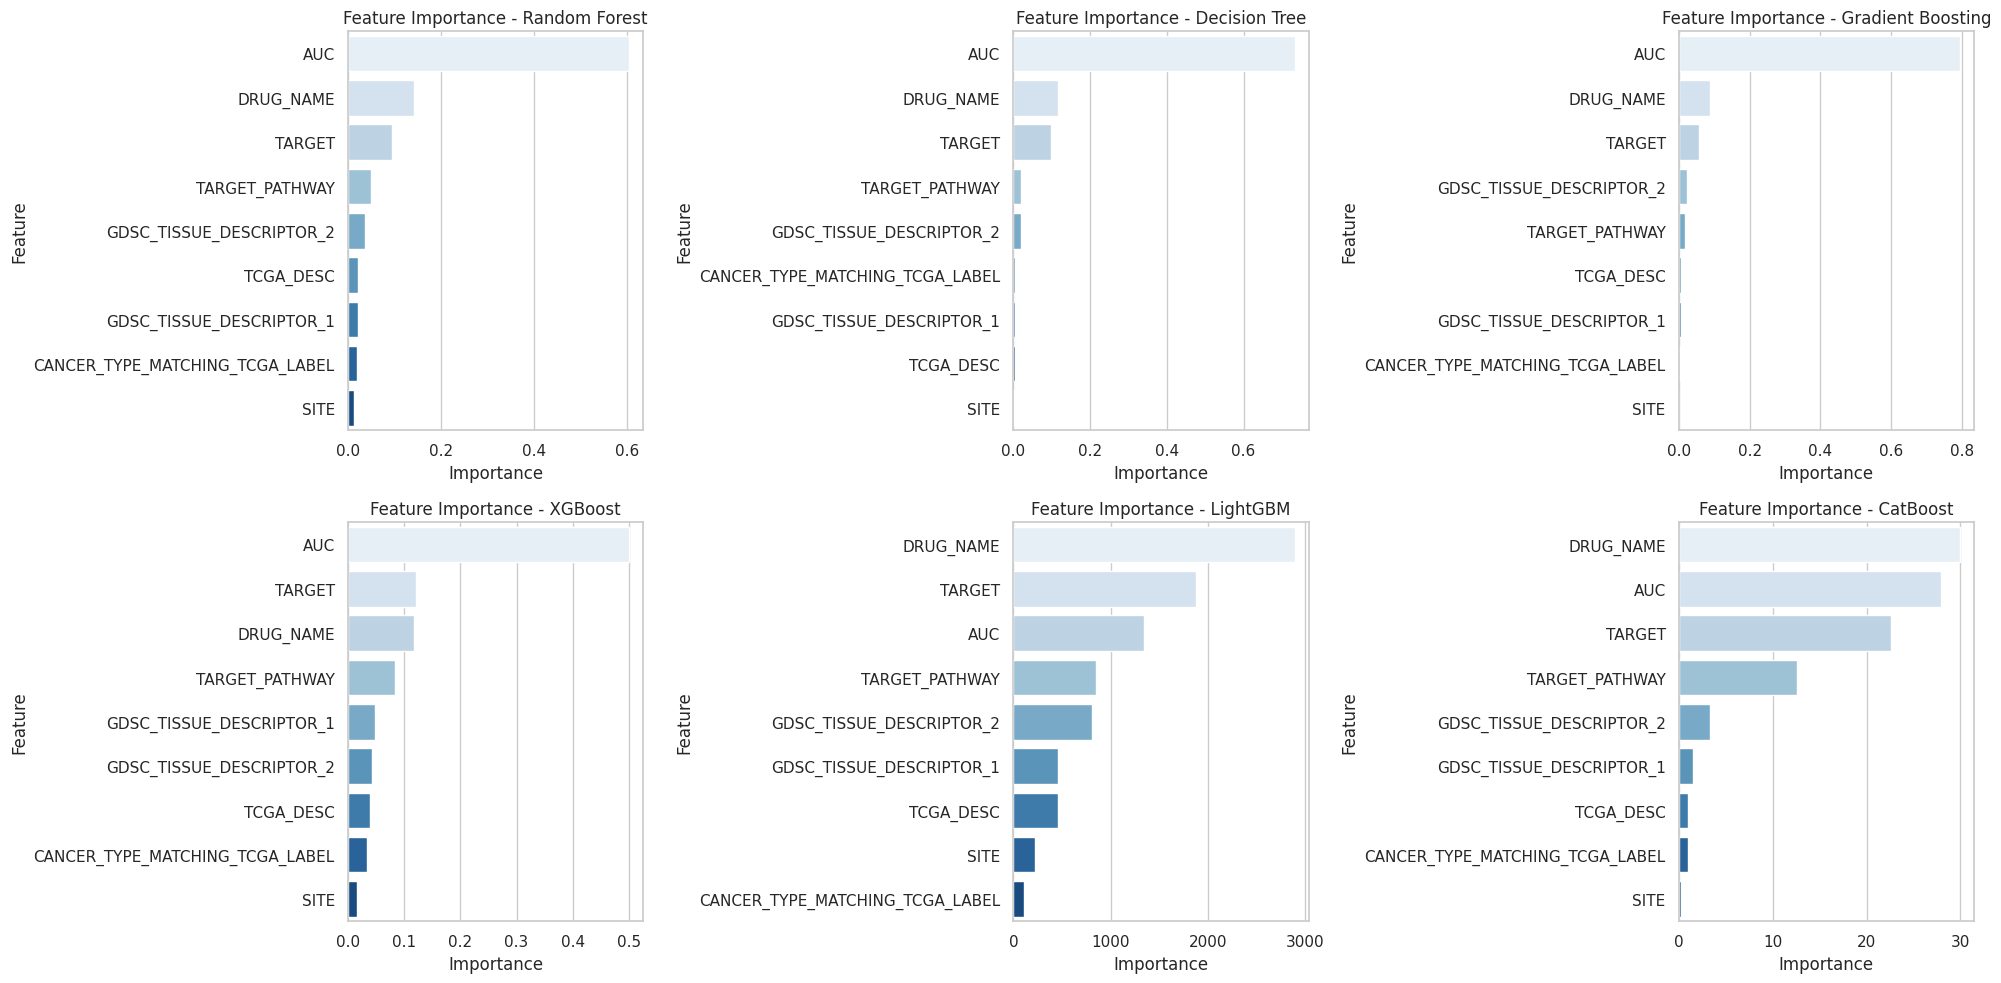

In [30]:
fig, axes = plt.subplots(2, 3, figsize=(20, 10))
axes = axes.flatten()

i = 0  

for name, model in models.items():
    
    if hasattr(model, "feature_importances_"):
        
        importances = model.feature_importances_
        features = X_train.columns
        
        df_imp = pd.DataFrame({
            "Feature": features,
            "Importance": importances
        }).sort_values("Importance", ascending=False).head(15)
        
        sns.barplot(
            data=df_imp,
            x="Importance",
            y="Feature",
            ax=axes[i],
            palette="Blues"
        )
        
        # Set plot title and labels
        axes[i].set_title(f"Feature Importance - {name}")
        axes[i].set_xlabel("Importance")
        axes[i].set_ylabel("Feature")
        
        i += 1  

for j in range(i, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()

plt.show()

# **Part 9 - Metrics and evaluations**

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(


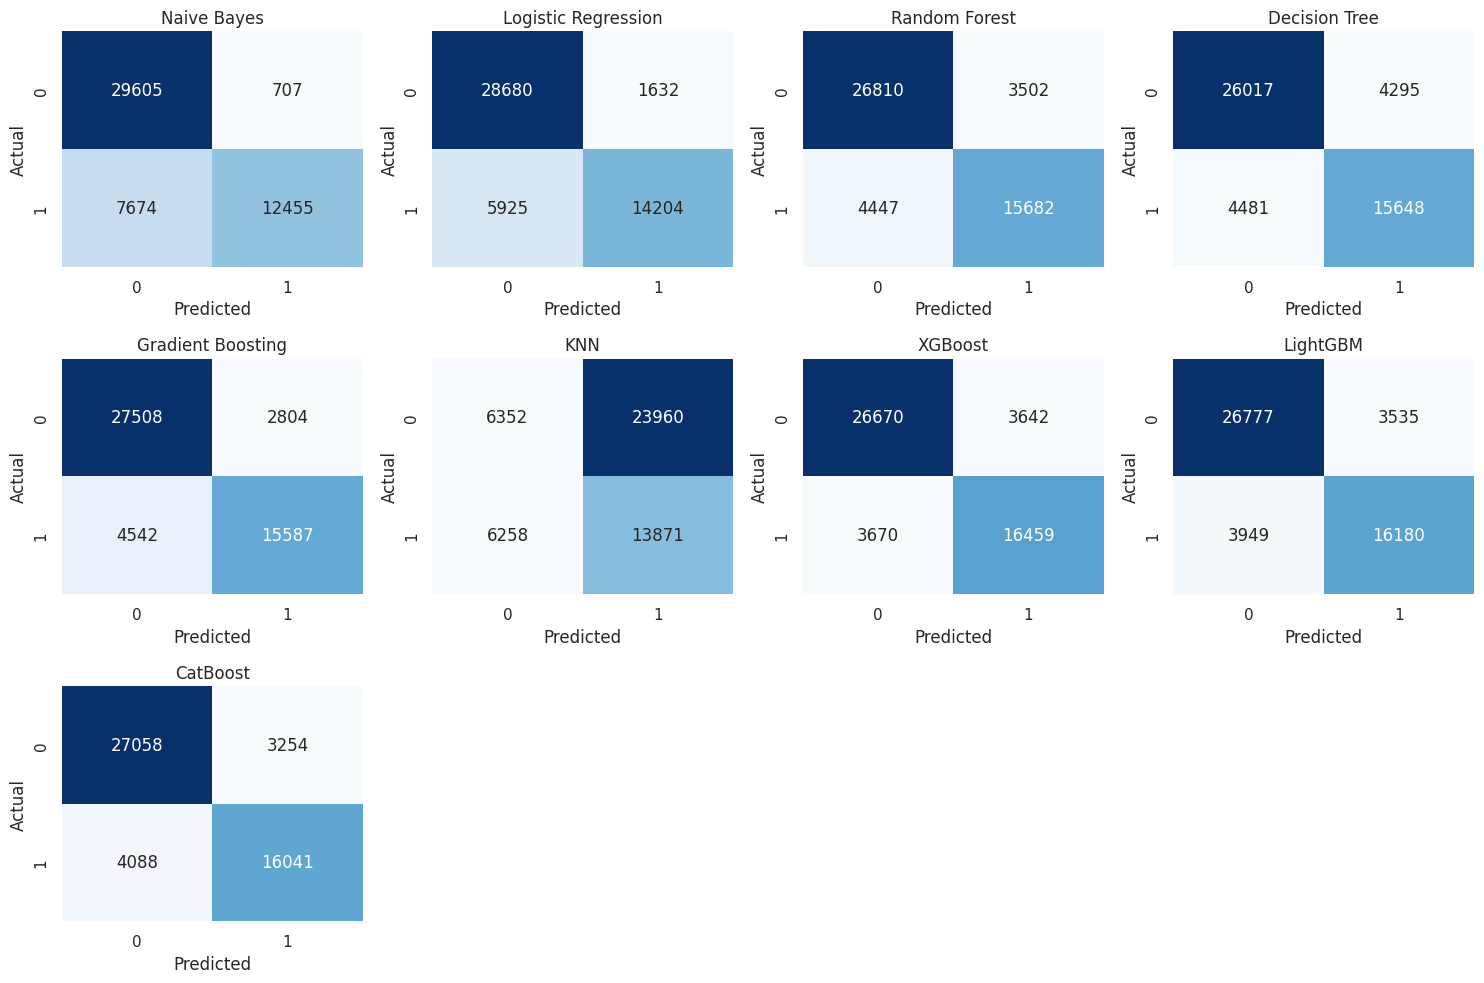

In [31]:
fig, axes = plt.subplots(3, 4, figsize=(15, 10))
axes = axes.flatten()

for ax, (name, model) in zip(axes, models.items()):
    
    y_pred = model.predict(X_test)
    
    cm = confusion_matrix(y_test, y_pred)
    
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        ax=ax
    )
    
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

for i in range(len(models), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()

plt.show()

In [32]:
for name, model in models.items():
    
    y_pred = model.predict(X_test)
    
    print("=" * 60)
    print(f"Classification Report - {name}")
    print("=" * 60)
    
    print(classification_report(
        y_test,
        y_pred,
        target_names=["Medication (0)", "Medication (1)"],
        zero_division=0
    ))

Classification Report - Naive Bayes
                precision    recall  f1-score   support

Medication (0)       0.79      0.98      0.88     30312
Medication (1)       0.95      0.62      0.75     20129

      accuracy                           0.83     50441
     macro avg       0.87      0.80      0.81     50441
  weighted avg       0.85      0.83      0.83     50441

Classification Report - Logistic Regression
                precision    recall  f1-score   support

Medication (0)       0.83      0.95      0.88     30312
Medication (1)       0.90      0.71      0.79     20129

      accuracy                           0.85     50441
     macro avg       0.86      0.83      0.84     50441
  weighted avg       0.86      0.85      0.85     50441

Classification Report - Random Forest
                precision    recall  f1-score   support

Medication (0)       0.86      0.88      0.87     30312
Medication (1)       0.82      0.78      0.80     20129

      accuracy                    

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(


Classification Report - KNN
                precision    recall  f1-score   support

Medication (0)       0.50      0.21      0.30     30312
Medication (1)       0.37      0.69      0.48     20129

      accuracy                           0.40     50441
     macro avg       0.44      0.45      0.39     50441
  weighted avg       0.45      0.40      0.37     50441

Classification Report - XGBoost
                precision    recall  f1-score   support

Medication (0)       0.88      0.88      0.88     30312
Medication (1)       0.82      0.82      0.82     20129

      accuracy                           0.86     50441
     macro avg       0.85      0.85      0.85     50441
  weighted avg       0.86      0.86      0.86     50441

Classification Report - LightGBM
                precision    recall  f1-score   support

Medication (0)       0.87      0.88      0.88     30312
Medication (1)       0.82      0.80      0.81     20129

      accuracy                           0.85     50441
   

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(


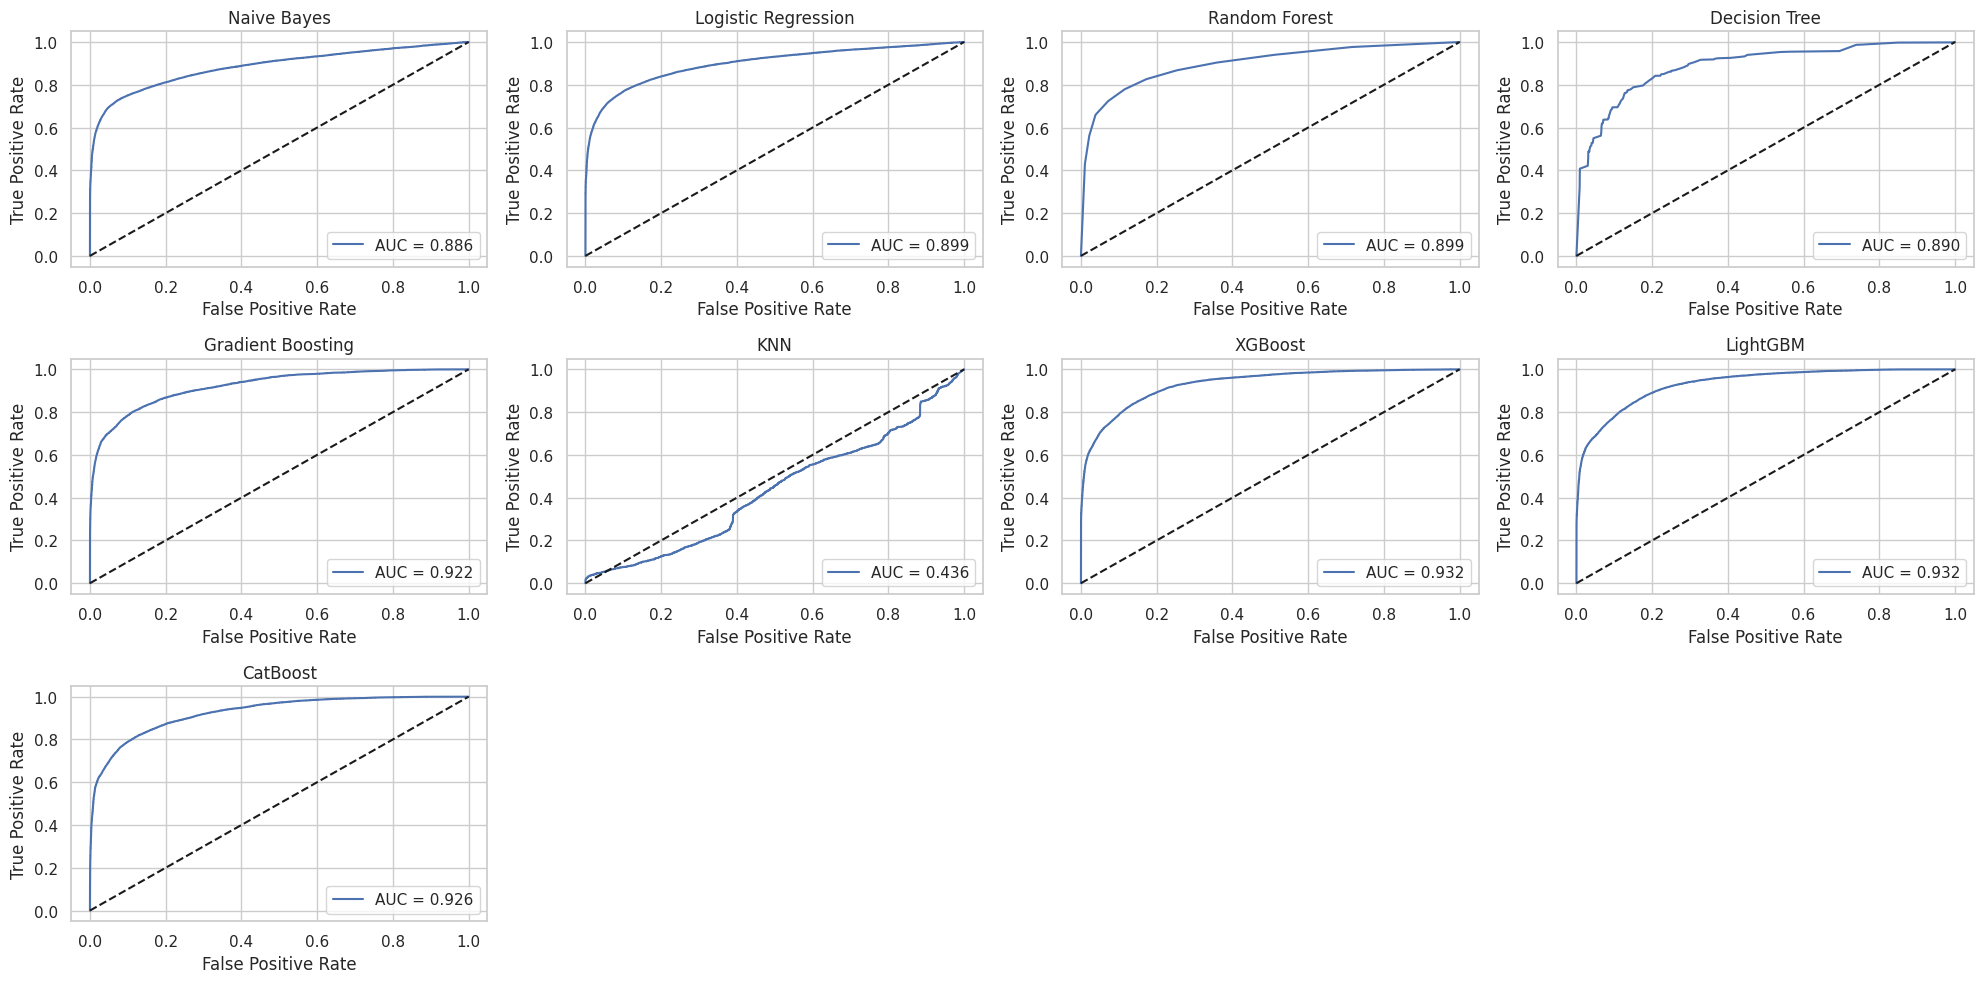

In [33]:
fig, axes = plt.subplots(3, 4, figsize=(20, 10))
axes = axes.flatten()

for ax, (name, model) in zip(axes, models.items()):
    
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
    else:
        y_proba = model.decision_function(X_test)
    
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    
    roc_auc = auc(fpr, tpr)
    
    ax.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
    
    ax.plot([0, 1], [0, 1], "k--")
    
    ax.set_title(name)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    
    ax.legend(loc="lower right")

for i in range(len(models), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()

plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(


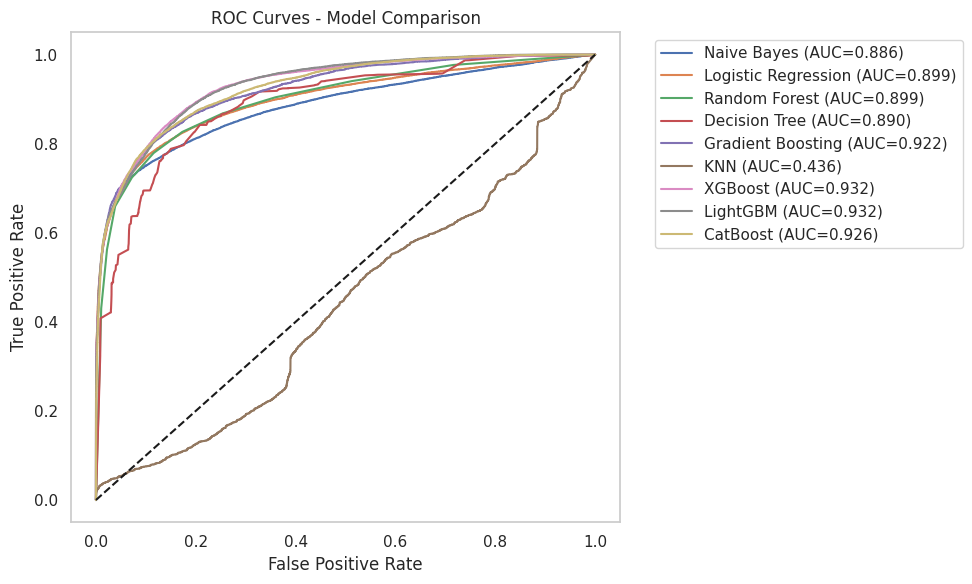

In [34]:
plt.figure(figsize=(10,6))

for name, model in models.items():

    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
    else:
        y_proba = model.decision_function(X_test)

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.3f})")

plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - Model Comparison")

plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.grid(False)

plt.show()

In [35]:
save_path = r"C:\Users\rafae.RAFAEL_NOTEBOOK\Downloads\Genomics of Drug Sensitivity in Cancer (GDSC)\models"
os.makedirs(save_path, exist_ok=True)

trained_models = {}

for name, model in tqdm(models.items(), desc="Training and saving models"):
       
    trained_models[name] = model
    
    filename = name.replace(" ", "_").lower() + ".pkl"
    filepath = os.path.join(save_path, filename)
    
    joblib.dump(model, filepath)
    
    print(f"Model saved: {filepath}")

Training and saving models: 100%|██████████| 9/9 [00:00<00:00, 84.29it/s]

Model saved: C:\Users\rafae.RAFAEL_NOTEBOOK\Downloads\Genomics of Drug Sensitivity in Cancer (GDSC)\models/naive_bayes.pkl
Model saved: C:\Users\rafae.RAFAEL_NOTEBOOK\Downloads\Genomics of Drug Sensitivity in Cancer (GDSC)\models/logistic_regression.pkl
Model saved: C:\Users\rafae.RAFAEL_NOTEBOOK\Downloads\Genomics of Drug Sensitivity in Cancer (GDSC)\models/random_forest.pkl
Model saved: C:\Users\rafae.RAFAEL_NOTEBOOK\Downloads\Genomics of Drug Sensitivity in Cancer (GDSC)\models/decision_tree.pkl
Model saved: C:\Users\rafae.RAFAEL_NOTEBOOK\Downloads\Genomics of Drug Sensitivity in Cancer (GDSC)\models/gradient_boosting.pkl
Model saved: C:\Users\rafae.RAFAEL_NOTEBOOK\Downloads\Genomics of Drug Sensitivity in Cancer (GDSC)\models/knn.pkl
Model saved: C:\Users\rafae.RAFAEL_NOTEBOOK\Downloads\Genomics of Drug Sensitivity in Cancer (GDSC)\models/xgboost.pkl
Model saved: C:\Users\rafae.RAFAEL_NOTEBOOK\Downloads\Genomics of Drug Sensitivity in Cancer (GDSC)\models/lightgbm.pkl
Model saved: 

# **Part 10 - Final result**

In [36]:
trained_models = {}
metrics = []

# Train models
for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    trained_models[name] = model

# Evaluate models
for name, model in trained_models.items():
    
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred, pos_label=1, zero_division=0)
    f1 = f1_score(y_test, y_pred, pos_label=1, zero_division=0)

    metrics.append({
        "Model": name,
        "Accuracy": acc,
        "Recall": recall,
        "F1-score": f1
    })

metrics_df = pd.DataFrame(metrics).sort_values("Recall", ascending=False)
best_recall = metrics_df["Recall"].max()

def highlight_best(row):
    return ["background-color: lightgreen"] * len(row) if row["Recall"] == best_recall else [""] * len(row)

metrics_df.style.apply(highlight_best, axis=1)

metrics_df

Training Naive Bayes...
Training Logistic Regression...
Training Random Forest...
Training Decision Tree...
Training Gradient Boosting...
Training KNN...
Training XGBoost...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [16:21:28] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Training LightGBM...
[LightGBM] [Info] Number of positive: 100889, number of negative: 90706
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003982 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 808
[LightGBM] [Info] Number of data points in the train set: 191595, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
Training CatBoost...


,Model,Accuracy,Recall,F1-score
6,XGBoost,0.855039,0.817676,0.818245
7,LightGBM,0.851629,0.803815,0.812167
8,CatBoost,0.854444,0.796910,0.813768
2,Random Forest,0.842410,0.779075,0.797802
3,Decision Tree,0.826015,0.777386,0.780994
4,Gradient Boosting,0.854365,0.774355,0.809294
5,KNN,0.672608,0.717373,0.636207
1,Logistic Regression,0.850181,0.705649,0.789879
0,Naive Bayes,0.833845,0.618759,0.748250


- **Among all tested models, XGBoost achieved the highest recall (0.68), indicating superior ability to identify drug-sensitive cancer cell lines. Tree-based ensemble models (LightGBM, CatBoost, Random Forest) also demonstrated competitive performance. Simpler linear models showed lower recall, suggesting limited capacity to capture complex drug–genomic interactions.**

In [37]:
import os
import joblib
import shutil

save_dir = "/kaggle/working/classification_package"
os.makedirs(save_dir, exist_ok=True)

# 1) Save all trained classification models
for name, model in trained_models.items():
    filename = name.lower().replace(" ", "_") + "_classification_model.pkl"
    filepath = os.path.join(save_dir, filename)

    joblib.dump(model, filepath)
    print("Saved model:", filepath)

joblib.dump(
    list(X.columns),
    os.path.join(save_dir, "classification_features.pkl")
)

joblib.dump(
    encoder,
    os.path.join(save_dir, "classification_encoder.pkl")
)

if "num_imputer" in globals():
    joblib.dump(
        num_imputer,
        os.path.join(save_dir, "classification_num_imputer.pkl")
    )

if "cat_imputer" in globals():
    joblib.dump(
        cat_imputer,
        os.path.join(save_dir, "classification_cat_imputer.pkl")
    )

if "scaler" in globals():
    joblib.dump(
        scaler,
        os.path.join(save_dir, "classification_scaler.pkl")
    )

results_df.to_csv(
    os.path.join(save_dir, "classification_results.csv"),
    index=False
)

shutil.make_archive(
    "/kaggle/working/classification_package",
    "zip",
    save_dir
)

print("Classification package ready:")
print("/kaggle/working/classification_package.zip")

Saved model: /kaggle/working/classification_package/naive_bayes_classification_model.pkl
Saved model: /kaggle/working/classification_package/logistic_regression_classification_model.pkl
Saved model: /kaggle/working/classification_package/random_forest_classification_model.pkl
Saved model: /kaggle/working/classification_package/decision_tree_classification_model.pkl
Saved model: /kaggle/working/classification_package/gradient_boosting_classification_model.pkl
Saved model: /kaggle/working/classification_package/knn_classification_model.pkl
Saved model: /kaggle/working/classification_package/xgboost_classification_model.pkl
Saved model: /kaggle/working/classification_package/lightgbm_classification_model.pkl
Saved model: /kaggle/working/classification_package/catboost_classification_model.pkl
Classification package ready:
/kaggle/working/classification_package.zip
